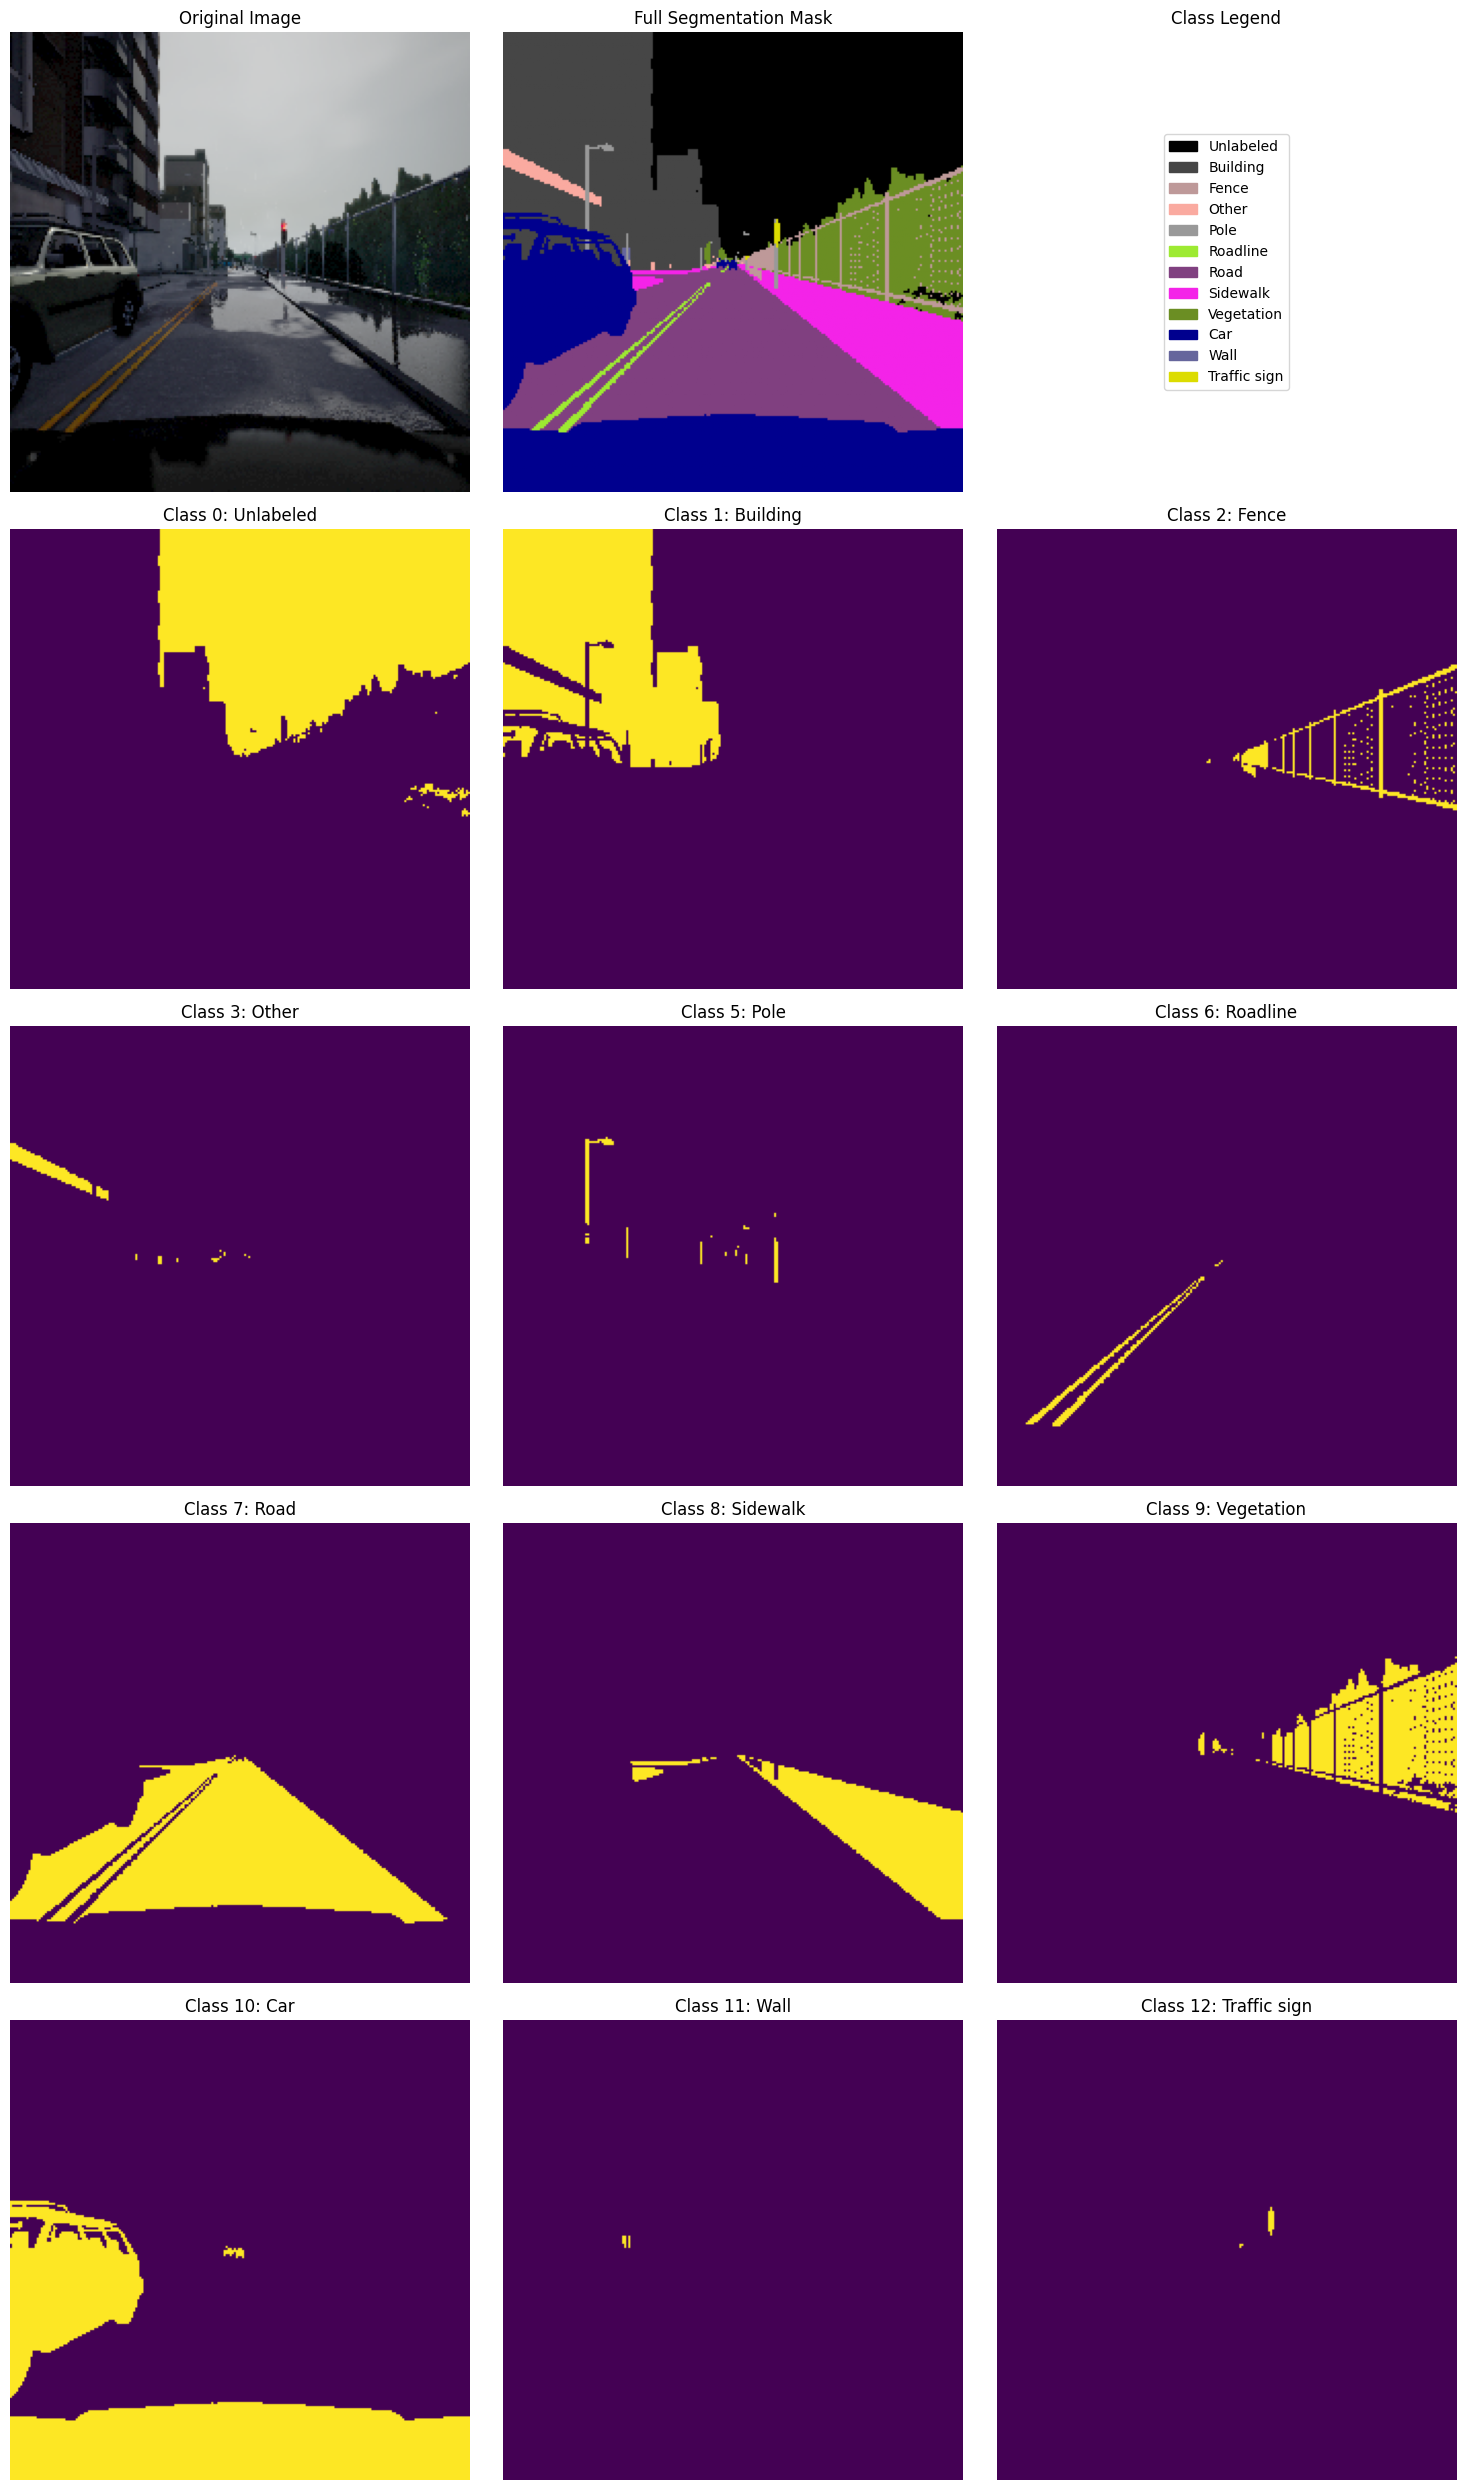

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from matplotlib.colors import ListedColormap

#image 224*224

def visualize_segmentation_classes(image_path, mask_path, output_dir=None):
    """
    Visualize the input image, full segmentation mask, and individual class masks
    
    Args:
        image_path: Path to the input image
        mask_path: Path to the corresponding segmentation mask
        output_dir: Directory to save visualizations (if None, only displays)
    """
    # Class names for the dataset
    class_names = [
        "Unlabeled", "Building", "Fence", "Other", "Pedestrian", 
        "Pole", "Roadline", "Road", "Sidewalk", "Vegetation", 
        "Car", "Wall", "Traffic sign"
    ]
    
    # Define a colormap for visualization
    colors = [
        [0, 0, 0],        # Unlabeled - black
        [70, 70, 70],     # Building - dark gray
        [190, 153, 153],  # Fence - light brown
        [250, 170, 160],  # Other - salmon
        [220, 20, 60],    # Pedestrian - crimson
        [153, 153, 153],  # Pole - gray
        [157, 234, 50],   # Roadline - bright green
        [128, 64, 128],   # Road - purple
        [244, 35, 232],   # Sidewalk - pink
        [107, 142, 35],   # Vegetation - olive green
        [0, 0, 142],      # Car - dark blue
        [102, 102, 156],  # Wall - slate blue
        [220, 220, 0]     # Traffic sign - yellow
    ]
    # Normalize colors to [0, 1] for matplotlib
    colors = np.array(colors) / 255.0
    cmap = ListedColormap(colors)
    
    # Load image and mask
    image = Image.open(image_path).convert('RGB')
    mask = Image.open(mask_path)
    
    # Convert mask to numpy array and get first channel (class IDs)
    mask_array = np.array(mask)
    if len(mask_array.shape) == 3:
        class_mask = mask_array[:, :, 0]  # Extract first channel
    else:
        class_mask = mask_array
    
    # Get unique classes in this mask
    unique_classes = np.unique(class_mask)
    
    # Set up the figure layout
    num_classes = len(unique_classes)
    fig_rows = int(np.ceil((num_classes + 2) / 3))  # +2 for image and full mask
    
    fig, axes = plt.subplots(fig_rows, 3, figsize=(15, 5 * fig_rows))
    if fig_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Plot original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Plot full segmentation mask with color mapping
    colored_mask = cmap(class_mask)
    axes[0, 1].imshow(colored_mask)
    axes[0, 1].set_title('Full Segmentation Mask')
    axes[0, 1].axis('off')
    
    # Create a legend for the classes
    legend_elements = [plt.Rectangle((0, 0), 1, 1, color=colors[i], label=class_names[i]) 
                      for i in range(len(class_names)) if i in unique_classes]
    axes[0, 2].legend(handles=legend_elements, loc='center')
    axes[0, 2].axis('off')
    axes[0, 2].set_title('Class Legend')
    
    # Plot individual class masks
    idx = 0
    for row in range(1, fig_rows):
        for col in range(3):
            if idx < num_classes:
                class_id = unique_classes[idx]
                idx += 1
                
                # Create binary mask for this class
                binary_mask = (class_mask == class_id).astype(np.uint8)
                
                # Plot the binary mask
                axes[row, col].imshow(binary_mask)
                axes[row, col].set_title(f'Class {class_id}: {class_names[class_id]}')
                axes[row, col].axis('off')
            else:
                axes[row, col].axis('off')
    
    plt.tight_layout()
    
    # Save figure if output directory is provided
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        base_name = os.path.basename(image_path).split('.')[0]
        plt.savefig(os.path.join(output_dir, f"{base_name}_visualization.png"))
    
    plt.show()



# Example usage
if __name__ == "__main__":
    # Path to your dataset
    dataset_path = "Dataset/1/dataset_224/train"

    # Alternatively, visualize a specific image and its mask
    image_path = "Dataset/1/dataset_224/train/images/02_00_000.png"
    mask_path = "Dataset/1/dataset_224/train/labels/02_00_000.png"
    visualize_segmentation_classes(image_path, mask_path)

In [2]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import numpy as np

class SegmentationDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir (string): Path to the dataset directory (Dataset/1/dataset_224/)
            split (string): 'train' or 'test'
            transform (callable, optional): Optional transform to be applied on images
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        
        # Define paths
        self.image_dir = os.path.join(root_dir, split, 'images')
        self.mask_dir = os.path.join(root_dir, split, 'labels')
        
        # Get list of files
        self.images = sorted(os.listdir(self.image_dir))
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image and mask
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)
        
        # Convert to numpy arrays
        image = np.array(image)
        mask = np.array(mask)
        
        # Extract first channel of mask (class IDs)
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]
        
        # Convert to torch tensors
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()
        
        # Apply transforms if any
        if self.transform is not None:
            image = self.transform(image)
        
        return image, mask

def get_data_loaders(data_dir, batch_size=8, num_workers=4):
    """Create train and test data loaders"""
    
    # Define transforms
    transform = transforms.Compose([
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
    ])
    
    # Create datasets
    train_dataset = SegmentationDataset(
        root_dir=data_dir,
        split='train',
        transform=transform
    )
    
    test_dataset = SegmentationDataset(
        root_dir=data_dir,
        split='test',
        transform=transform
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, test_loader

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics.segmentation import MeanIoU
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

def train_model(model, train_loader, test_loader, num_epochs=50, device='cuda'):
    """Train the FCN model"""
    
    # Move model to device
    model = model.to(device)
    
    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    
    # Initialize metrics
    metric = MeanIoU(num_classes=13).to(device)
    
    # Training history
    history = {
        'train_loss': [],
        'train_miou': [],
        'val_loss': [],
        'val_miou': []
    }
    
    # Training loop
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_miou = 0
        
        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Update metrics
            train_loss += loss.item()
            train_miou += metric(outputs.argmax(1), masks).item()
        
        # Calculate average metrics
        train_loss /= len(train_loader)
        train_miou /= len(train_loader)
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_miou = 0
        
        with torch.no_grad():
            for images, masks in test_loader:
                images = images.to(device)
                masks = masks.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, masks)
                
                val_loss += loss.item()
                val_miou += metric(outputs.argmax(1), masks).item()
        
        val_loss /= len(test_loader)
        val_miou /= len(test_loader)
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_miou'].append(train_miou)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Train mIoU: {train_miou:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val mIoU: {val_miou:.4f}')
    
    return history

def plot_training_history(history):
    """Plot training curves"""
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot loss
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title('Loss vs Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Plot mIoU
    ax2.plot(history['train_miou'], label='Train mIoU')
    ax2.plot(history['val_miou'], label='Validation mIoU')
    ax2.set_title('mIoU vs Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('mIoU')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def denormalize(tensor):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    mean = torch.tensor(mean).reshape(1, 3, 1, 1)
    std = torch.tensor(std).reshape(1, 3, 1, 1)
    tensor = tensor * std + mean
    return tensor
def visualize_predictions(model, test_loader, device='cuda', num_samples=5):
    """Visualize model predictions"""
    
    model.eval()
    
    # Class colors for visualization
    colors = [
        [0, 0, 0],        # Unlabeled
        [70, 70, 70],     # Building
        [190, 153, 153],  # Fence
        [250, 170, 160],  # Other
        [220, 20, 60],    # Pedestrian
        [153, 153, 153],  # Pole
        [157, 234, 50],   # Roadline
        [128, 64, 128],   # Road
        [244, 35, 232],   # Sidewalk
        [107, 142, 35],   # Vegetation
        [0, 0, 142],      # Car
        [102, 102, 156],  # Wall
        [220, 220, 0]     # Traffic sign
    ]
    colors = np.array(colors) / 255.0
    
    # Denormalization function
    def denormalize(x):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        # Denormalize: x = (x * std) + mean
        x = x.transpose(1, 2, 0)
        x = x * std + mean
        # Clip values to [0, 1] range
        x = np.clip(x, 0, 1)
        return x
    
    with torch.no_grad():
        for i, (images, masks) in enumerate(test_loader):
            if i >= num_samples:
                break
                
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            predictions = outputs.argmax(1)
            
            # Convert to numpy and denormalize
            images = images.cpu().numpy()
            masks = masks.cpu().numpy()
            predictions = predictions.cpu().numpy()
            
            # Plot results
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Original image (denormalized)
            denorm_img = denormalize(images[0])
            axes[0].imshow(denorm_img)
            axes[0].set_title('Input Image')
            axes[0].axis('off')
            
            # Ground truth
            mask_rgb = colors[masks[0]]
            axes[1].imshow(mask_rgb)
            axes[1].set_title('Ground Truth')
            axes[1].axis('off')
            
            # Prediction
            pred_rgb = colors[predictions[0]]
            axes[2].imshow(pred_rgb)
            axes[2].set_title('Prediction')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

class FCN32s(nn.Module):
    def __init__(self, num_classes=13):
        super(FCN32s, self).__init__()
        # Load pretrained VGG16
        vgg = models.vgg16(pretrained=True)
        
        # Extract features from VGG
        self.features = vgg.features
        
        # Freeze the backbone weights
        for param in self.features.parameters():
            param.requires_grad = False
            
        # FCN32s head
        self.head = nn.Sequential(
            # FC6
            nn.Conv2d(512, 4096, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # FC7
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # Score
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )
        
        # Upsampling layer
        self.upsample = nn.ConvTranspose2d(num_classes, num_classes, 
                                          kernel_size=64, stride=32, 
                                          padding=16, bias=False)
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.ConvTranspose2d):
                m.weight.data.zero_()
                m.weight.data = self._bilinear_kernel(m.in_channels, m.out_channels, m.kernel_size[0])
                
    def _bilinear_kernel(self, in_channels, out_channels, kernel_size):
        factor = (kernel_size + 1) // 2
        if kernel_size % 2 == 1:
            center = factor - 1
        else:
            center = factor - 0.5
        og = np.ogrid[:kernel_size, :kernel_size]
        filt = (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)
        weight = np.zeros((out_channels, in_channels, kernel_size, kernel_size))
        for i in range(min(in_channels, out_channels)):
            weight[i, i] = filt
        return torch.from_numpy(weight).float()
        
    def forward(self, x):
        size = x.size()[2:]  # Original input size
        
        # VGG backbone
        x = self.features(x)
        
        # FCN head
        x = self.head(x)
        
        # Upsample to original size
        x = self.upsample(x)
        
        # Crop to match input size exactly
        x = x[:, :, :size[0], :size[1]]
        
        return x

class FCN16s(nn.Module):
    def __init__(self, num_classes=13):
        super(FCN16s, self).__init__()
        # Load pretrained VGG16
        vgg = models.vgg16(pretrained=True)
        
        # Split features at pool4
        features = list(vgg.features.children())
        self.features_low = nn.Sequential(*features[:24])  # until pool4
        self.features_high = nn.Sequential(*features[24:]) # after pool4
        
        # Freeze the backbone weights
        for param in self.features_low.parameters():
            param.requires_grad = False
        for param in self.features_high.parameters():
            param.requires_grad = False
            
        # FCN head
        self.head = nn.Sequential(
            # FC6
            nn.Conv2d(512, 4096, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # FC7
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # Score
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )
        
        # Skip connection layers
        self.score_pool4 = nn.Conv2d(512, num_classes, kernel_size=1)
        
        # Upsampling layers
        self.upscore2 = nn.ConvTranspose2d(num_classes, num_classes,
                                          kernel_size=4, stride=2,
                                          padding=1, bias=False)
        self.upscore16 = nn.ConvTranspose2d(num_classes, num_classes,
                                           kernel_size=32, stride=16,
                                           padding=8, bias=False)
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.ConvTranspose2d):
                m.weight.data.zero_()
                m.weight.data = self._bilinear_kernel(m.in_channels, m.out_channels, m.kernel_size[0])
                
    def _bilinear_kernel(self, in_channels, out_channels, kernel_size):
        factor = (kernel_size + 1) // 2
        if kernel_size % 2 == 1:
            center = factor - 1
        else:
            center = factor - 0.5
        og = np.ogrid[:kernel_size, :kernel_size]
        filt = (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)
        weight = np.zeros((out_channels, in_channels, kernel_size, kernel_size))
        for i in range(min(in_channels, out_channels)):
            weight[i, i] = filt
        return torch.from_numpy(weight).float()
        
    def forward(self, x):
        size = x.size()[2:]  # Original input size
        
        # VGG backbone (split)
        pool4 = self.features_low(x)
        x = self.features_high(pool4)
        
        # FCN head
        x = self.head(x)
        
        # Upsample and fuse with pool4
        x = self.upscore2(x)
        pool4_scores = self.score_pool4(pool4)
        
        # Add predictions
        x = x + pool4_scores[:, :, :x.size(2), :x.size(3)]
        
        # Upsample to original size
        x = self.upscore16(x)
        
        # Crop to match input size exactly
        x = x[:, :, :size[0], :size[1]]
        
        return x

class FCN8s(nn.Module):
    def __init__(self, num_classes=13):
        super(FCN8s, self).__init__()
        # Load pretrained VGG16
        vgg = models.vgg16(pretrained=True)
        
        # Split features
        features = list(vgg.features.children())
        self.features_low = nn.Sequential(*features[:17])   # until pool3
        self.features_mid = nn.Sequential(*features[17:24]) # until pool4
        self.features_high = nn.Sequential(*features[24:])  # after pool4
        
        # Freeze the backbone weights
        for param in self.features_low.parameters():
            param.requires_grad = False
        for param in self.features_mid.parameters():
            param.requires_grad = False
        for param in self.features_high.parameters():
            param.requires_grad = False
            
        # FCN head
        self.head = nn.Sequential(
            # FC6
            nn.Conv2d(512, 4096, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # FC7
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # Score
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )
        
        # Skip connection layers
        self.score_pool3 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.score_pool4 = nn.Conv2d(512, num_classes, kernel_size=1)
        
        # Upsampling layers
        self.upscore2_fr = nn.ConvTranspose2d(num_classes, num_classes,
                                             kernel_size=4, stride=2,
                                             padding=1, bias=False)
        self.upscore2_pool4 = nn.ConvTranspose2d(num_classes, num_classes,
                                                kernel_size=4, stride=2,
                                                padding=1, bias=False)
        self.upscore8 = nn.ConvTranspose2d(num_classes, num_classes,
                                          kernel_size=16, stride=8,
                                          padding=4, bias=False)
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.ConvTranspose2d):
                m.weight.data.zero_()
                m.weight.data = self._bilinear_kernel(m.in_channels, m.out_channels, m.kernel_size[0])
                
    def _bilinear_kernel(self, in_channels, out_channels, kernel_size):
        factor = (kernel_size + 1) // 2
        if kernel_size % 2 == 1:
            center = factor - 1
        else:
            center = factor - 0.5
        og = np.ogrid[:kernel_size, :kernel_size]
        filt = (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)
        weight = np.zeros((out_channels, in_channels, kernel_size, kernel_size))
        for i in range(min(in_channels, out_channels)):
            weight[i, i] = filt
        return torch.from_numpy(weight).float()
        
    def forward(self, x):
        size = x.size()[2:]  # Original input size
        
        # VGG backbone (split)
        pool3 = self.features_low(x)
        pool4 = self.features_mid(pool3)
        x = self.features_high(pool4)
        
        # FCN head
        x = self.head(x)
        
        # First fusion with pool4
        x = self.upscore2_fr(x)
        pool4_scores = self.score_pool4(pool4)
        x = x + pool4_scores[:, :, :x.size(2), :x.size(3)]
        
        # Second fusion with pool3
        x = self.upscore2_pool4(x)
        pool3_scores = self.score_pool3(pool3)
        x = x + pool3_scores[:, :, :x.size(2), :x.size(3)]
        
        # Final upsampling
        x = self.upscore8(x)
        
        # Crop to match input size exactly
        x = x[:, :, :size[0], :size[1]]
        
        return x

/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training FCN-32s...


Epoch 1/50: 100%|██████████| 500/500 [00:26<00:00, 19.07it/s]


Epoch 1/50:
Train Loss: 0.4541, Train mIoU: 0.6382
Val Loss: 0.3359, Val mIoU: 0.6760


Epoch 2/50: 100%|██████████| 500/500 [00:26<00:00, 18.94it/s]


...

Epoch 48/50:
Train Loss: 0.1496, Train mIoU: 0.8066
Val Loss: 0.1930, Val mIoU: 0.7768


Epoch 49/50: 100%|██████████| 500/500 [00:39<00:00, 12.78it/s]


Epoch 49/50:
Train Loss: 0.1494, Train mIoU: 0.8062
Val Loss: 0.1913, Val mIoU: 0.7835


Epoch 50/50: 100%|██████████| 500/500 [00:26<00:00, 18.54it/s]


Epoch 50/50:
Train Loss: 0.1483, Train mIoU: 0.8075
Val Loss: 0.1915, Val mIoU: 0.7820


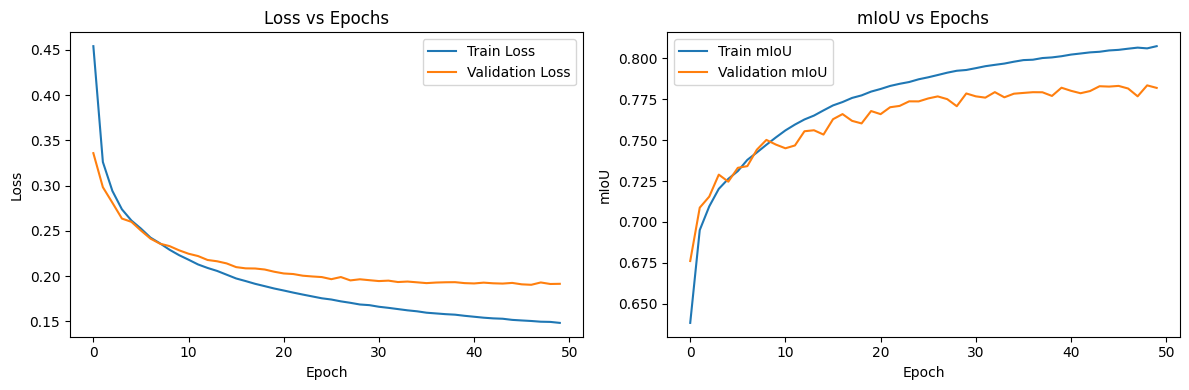

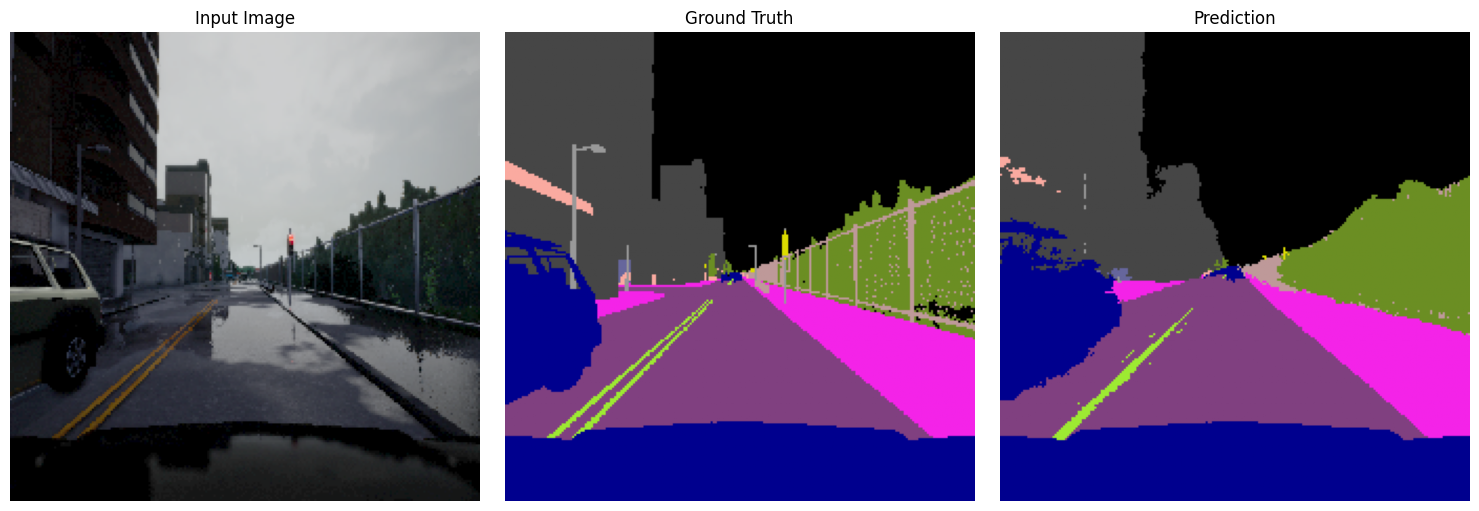

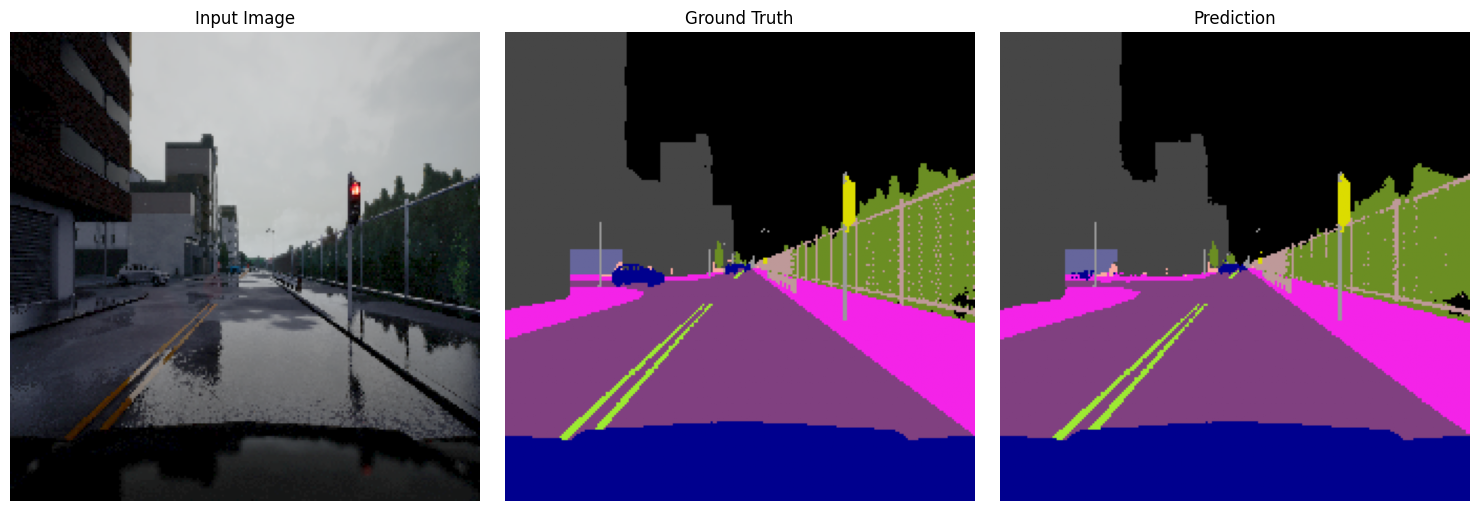

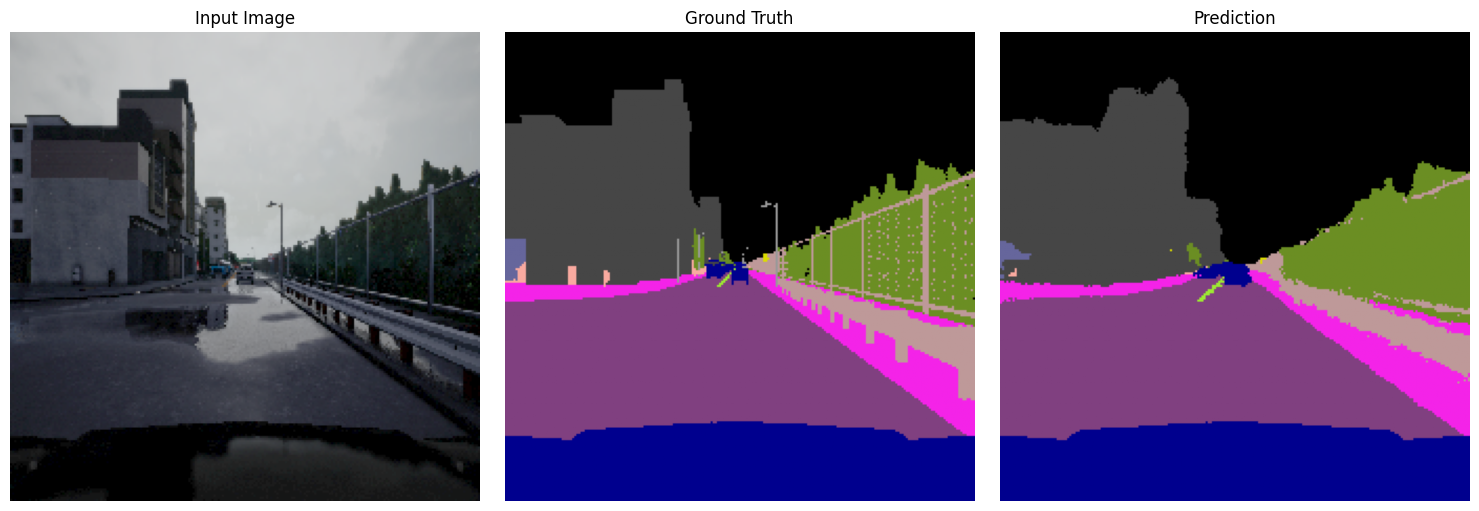

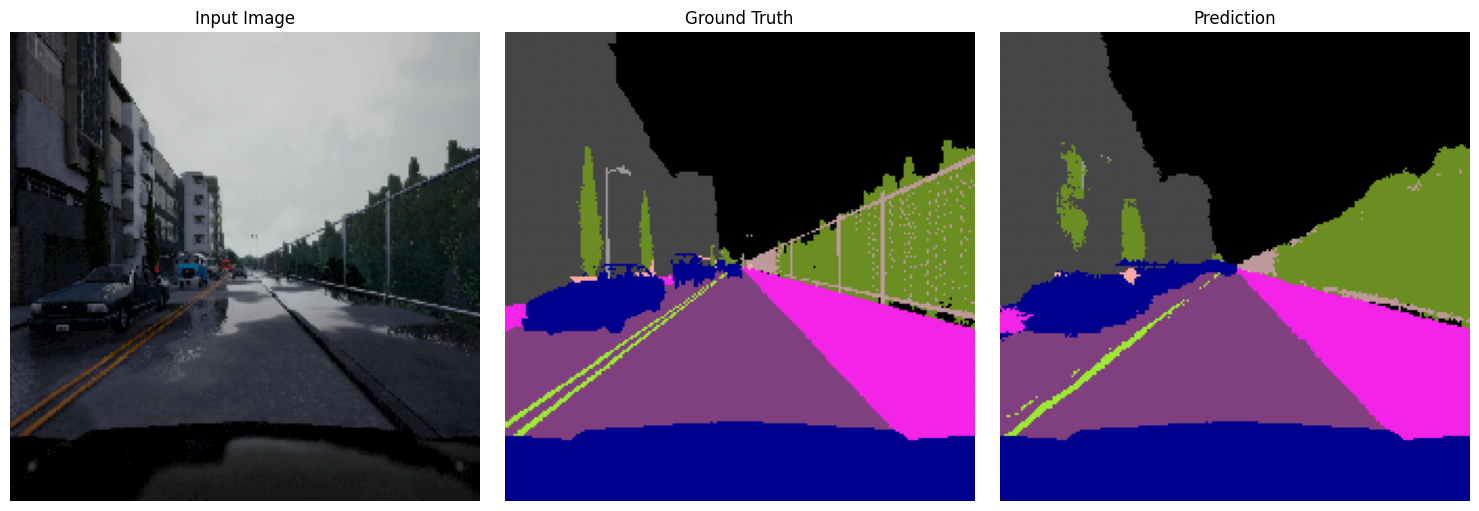

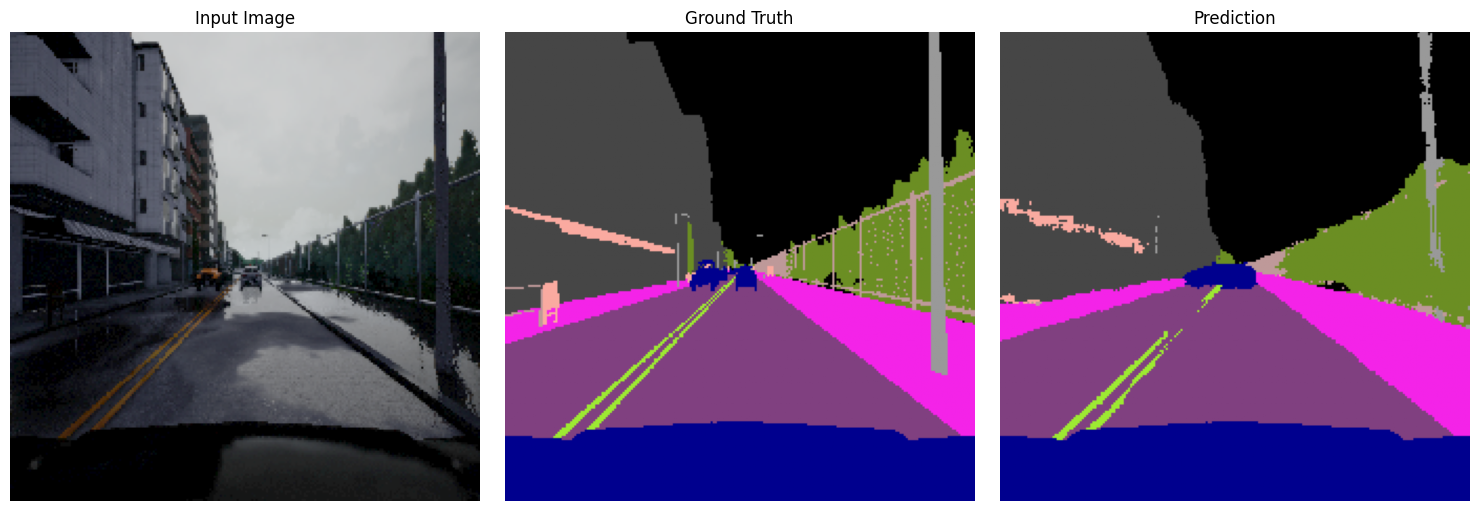


Training FCN-16s...


Epoch 1/50: 100%|██████████| 500/500 [00:26<00:00, 18.64it/s]


Epoch 1/50:
Train Loss: 0.4858, Train mIoU: 0.6548
Val Loss: 0.3313, Val mIoU: 0.7076


Epoch 2/50: 100%|██████████| 500/500 [00:37<00:00, 13.20it/s]


Epoch 2/50:
Train Loss: 0.3060, Train mIoU: 0.7255
Val Loss: 0.2856, Val mIoU: 0.7295


...

Epoch 48/50:
Train Loss: 0.1487, Train mIoU: 0.8117
Val Loss: 0.1803, Val mIoU: 0.7921


Epoch 49/50: 100%|██████████| 500/500 [00:53<00:00,  9.30it/s]


Epoch 49/50:
Train Loss: 0.1480, Train mIoU: 0.8126
Val Loss: 0.1801, Val mIoU: 0.7915


Epoch 50/50: 100%|██████████| 500/500 [00:51<00:00,  9.62it/s]


Epoch 50/50:
Train Loss: 0.1475, Train mIoU: 0.8126
Val Loss: 0.1808, Val mIoU: 0.7883


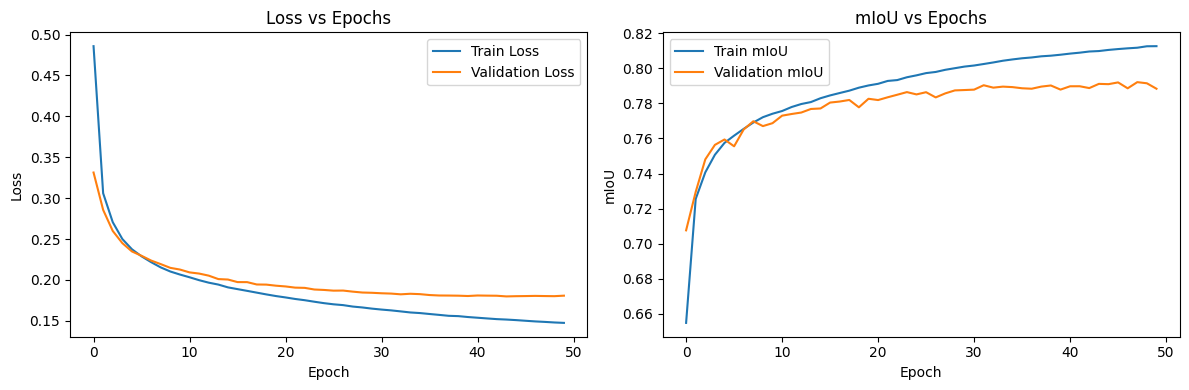

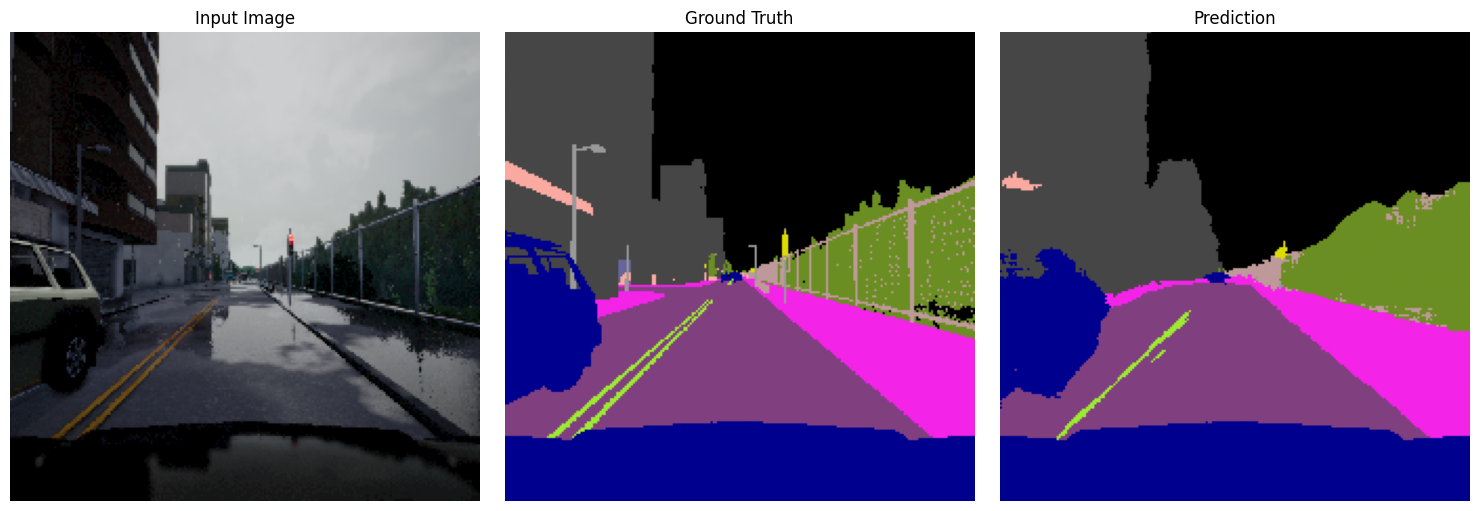

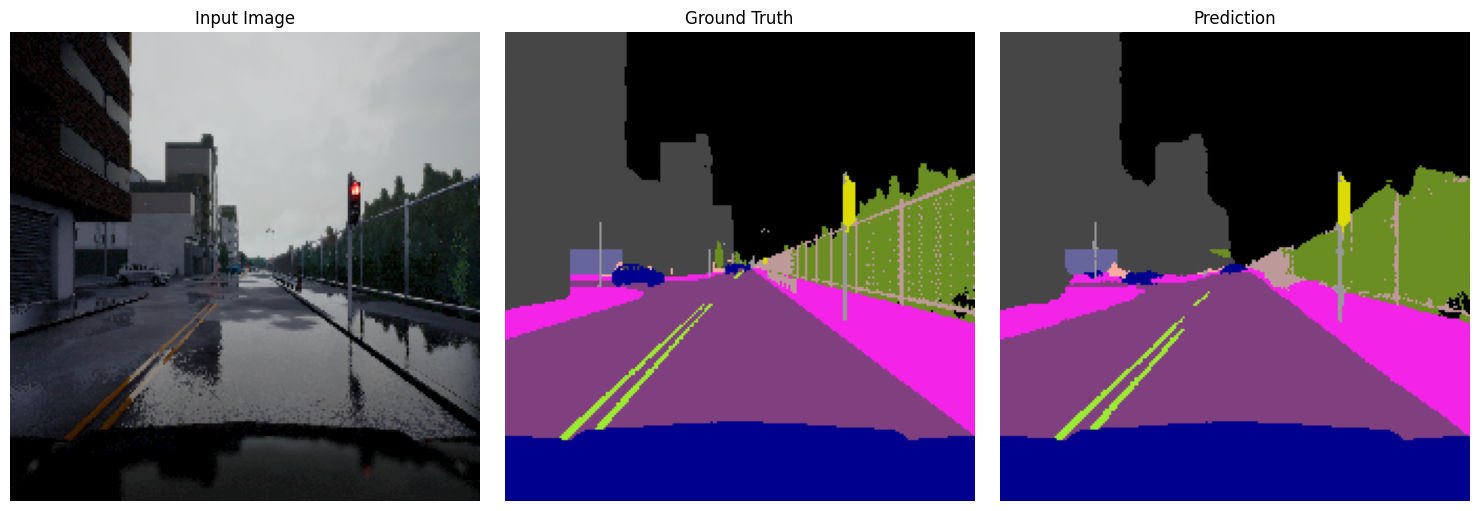

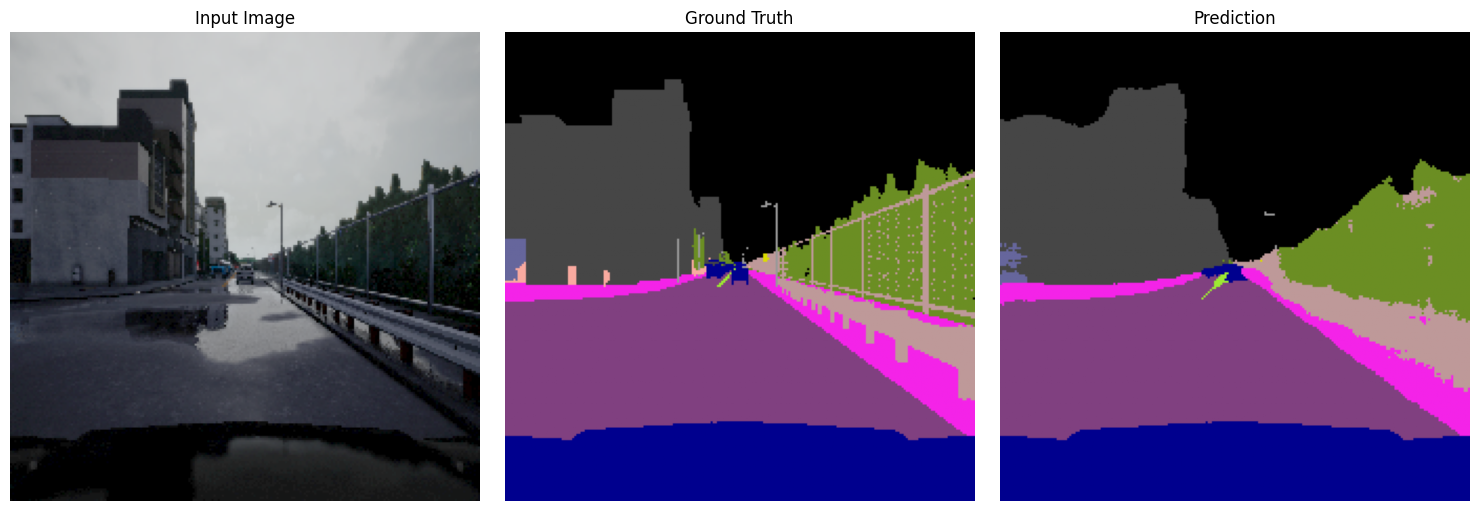

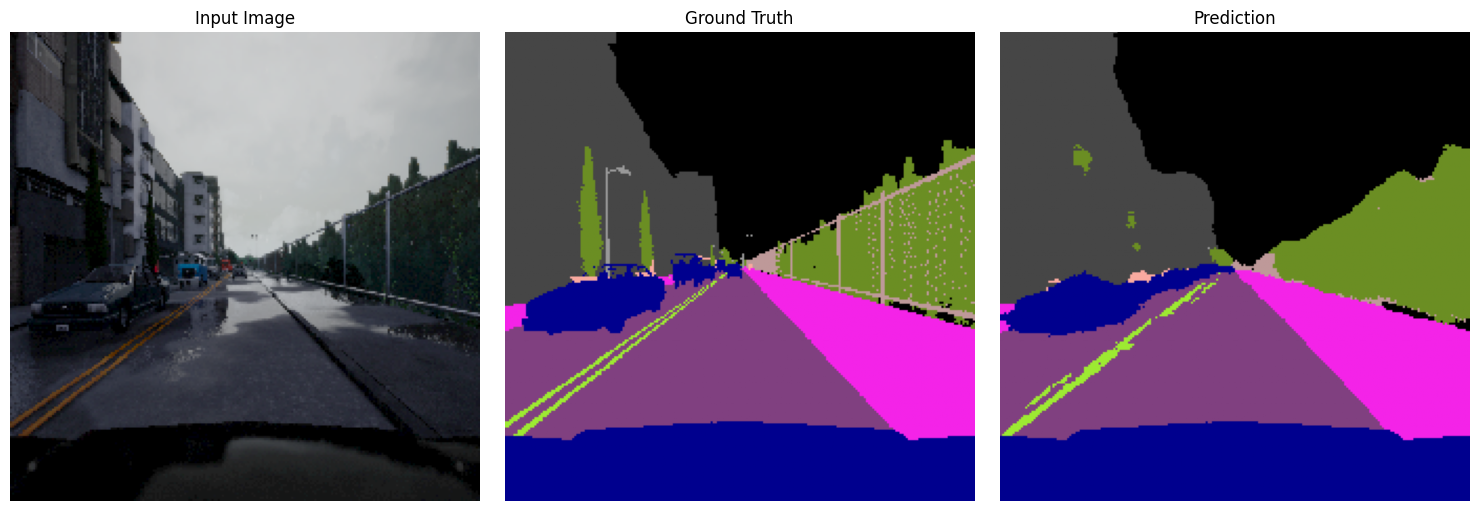

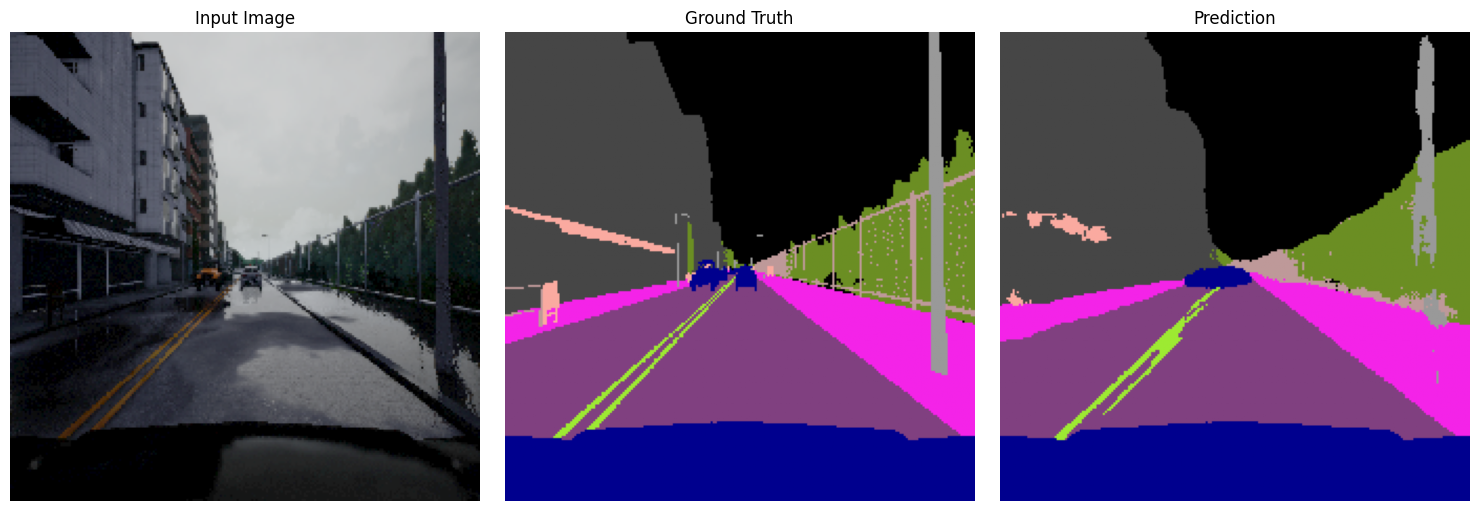


Training FCN-8s...


Epoch 1/50: 100%|██████████| 500/500 [00:51<00:00,  9.75it/s]


Epoch 1/50:
Train Loss: 0.6827, Train mIoU: 0.6560
Val Loss: 0.3906, Val mIoU: 0.7290


Epoch 2/50: 100%|██████████| 500/500 [00:53<00:00,  9.35it/s]


Epoch 2/50:
Train Loss: 0.3457, Train mIoU: 0.7398
Val Loss: 0.3019, Val mIoU: 0.7563


...

Epoch 48/50:
Train Loss: 0.1327, Train mIoU: 0.8281
Val Loss: 0.1542, Val mIoU: 0.8162


Epoch 49/50: 100%|██████████| 500/500 [00:25<00:00, 19.60it/s]


Epoch 49/50:
Train Loss: 0.1322, Train mIoU: 0.8283
Val Loss: 0.1535, Val mIoU: 0.8165


Epoch 50/50: 100%|██████████| 500/500 [00:25<00:00, 19.62it/s]


Epoch 50/50:
Train Loss: 0.1318, Train mIoU: 0.8286
Val Loss: 0.1533, Val mIoU: 0.8151


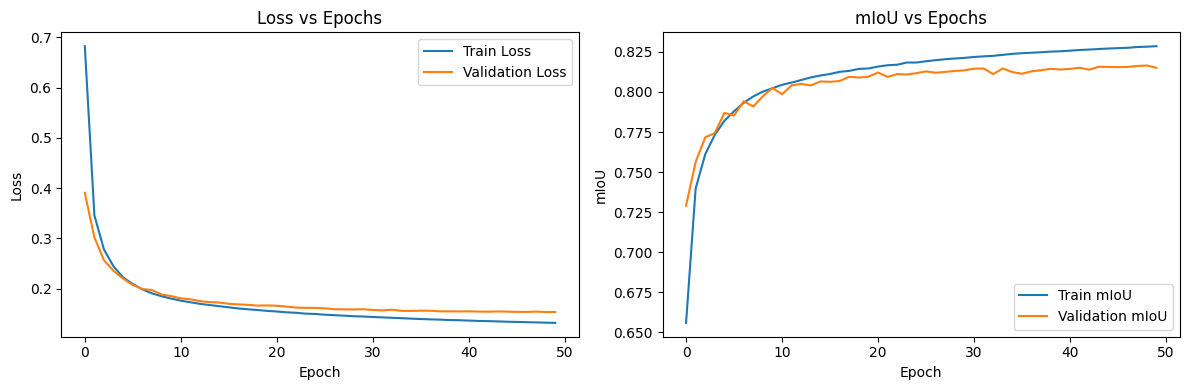

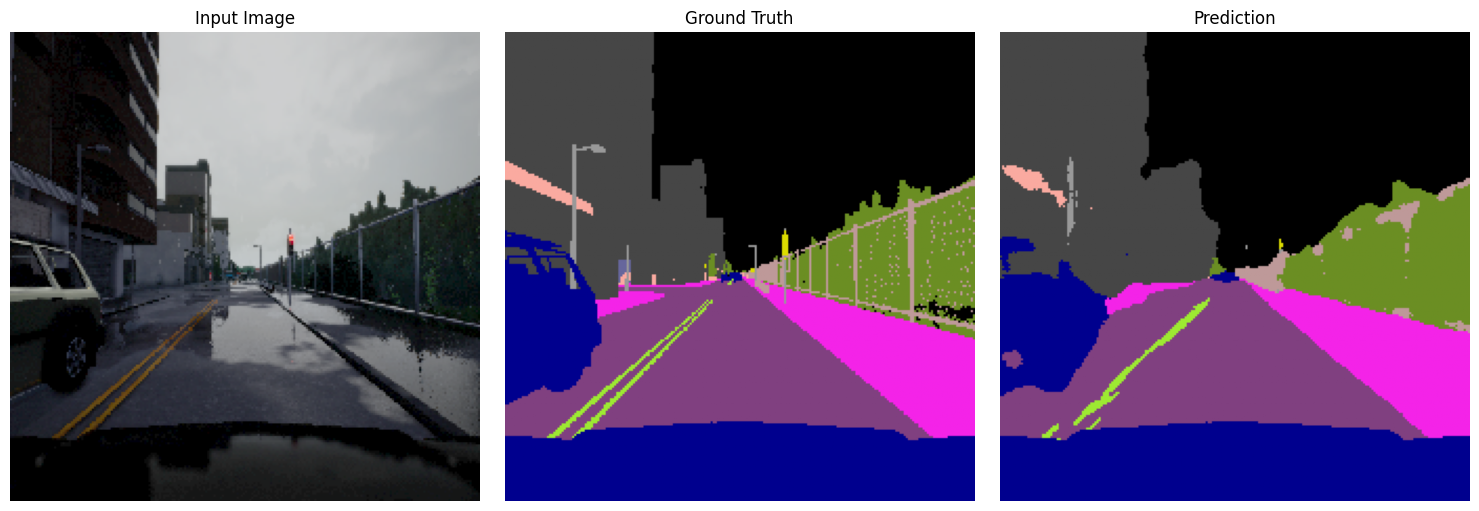

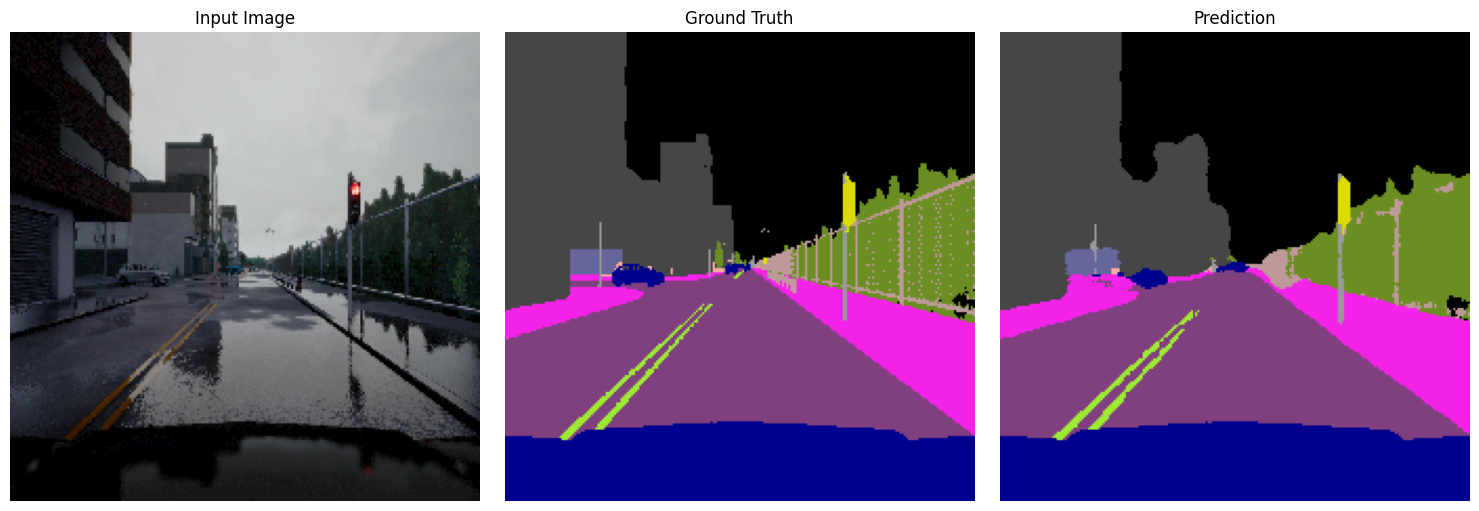

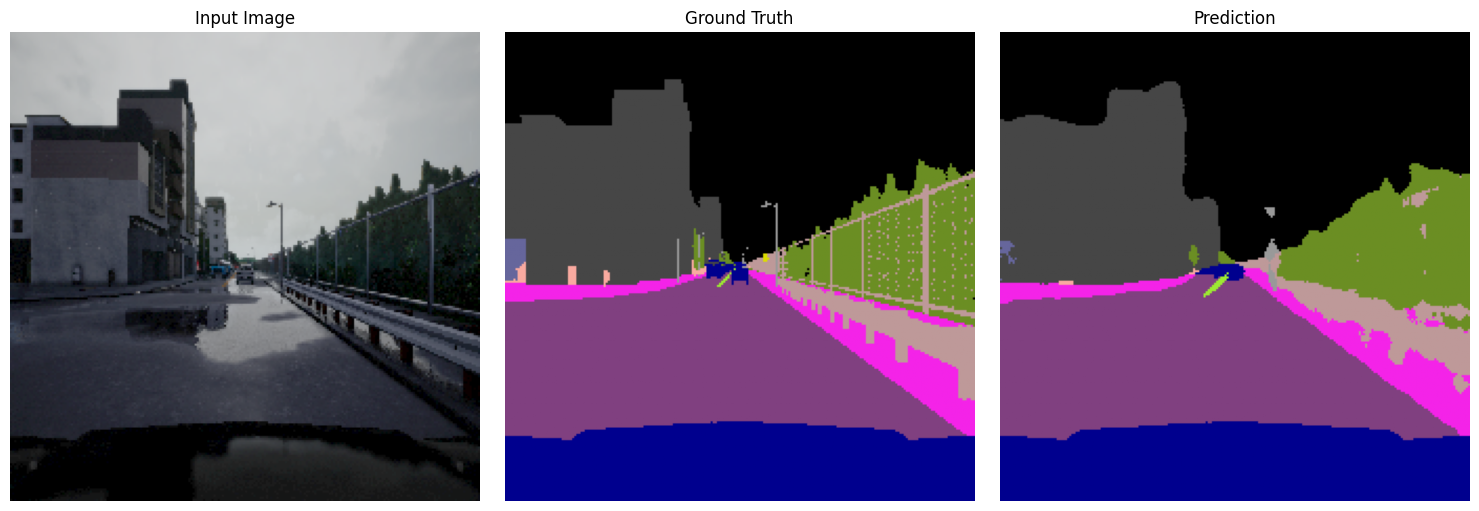

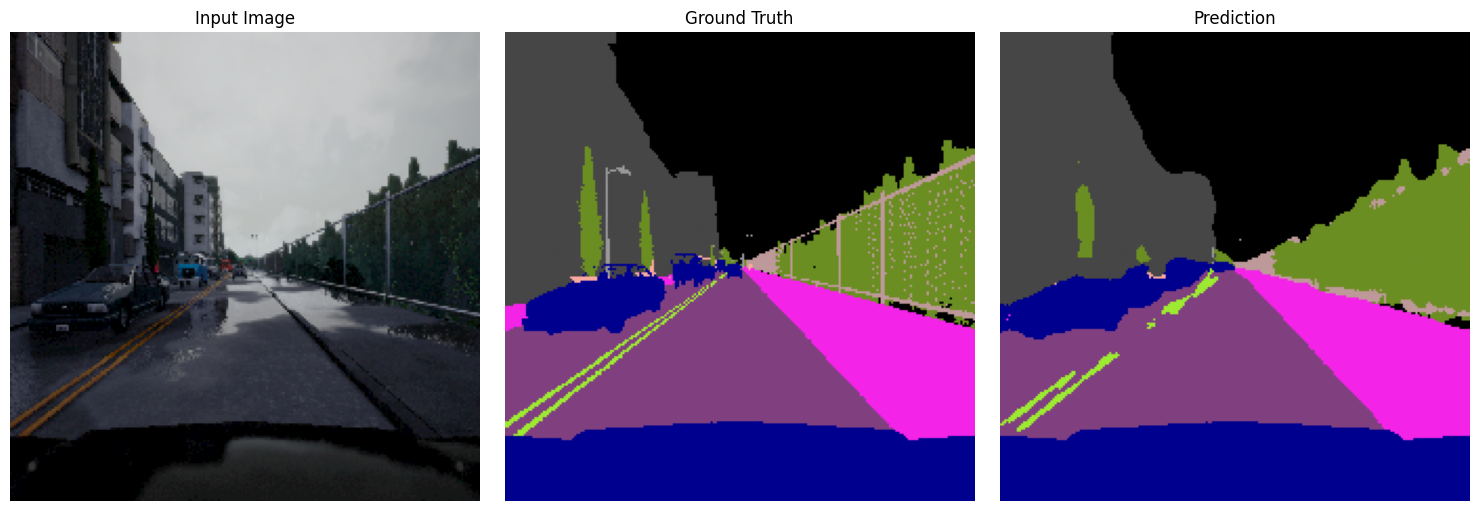

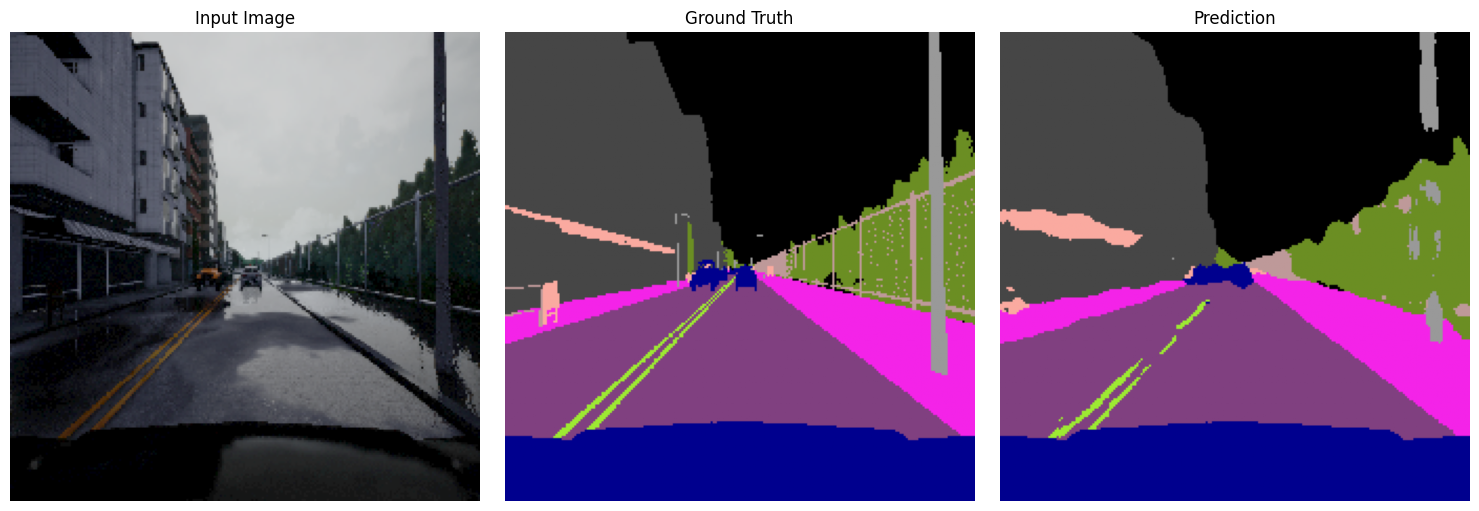

In [5]:
import torch
# from dataset import get_data_loaders
# from models import FCN32s, FCN16s, FCN8s
# from train import train_model, plot_training_history, visualize_predictions

def main():
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Create data loaders
    data_dir = "Dataset/1/dataset_224"
    train_loader, test_loader = get_data_loaders(data_dir, batch_size=4)
    
    # Train and evaluate each FCN variant
    models = {
        'FCN-32s': FCN32s(num_classes=13),
        'FCN-16s': FCN16s(num_classes=13),
        'FCN-8s': FCN8s(num_classes=13)
    }
    
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        
        # Train model
        history = train_model(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            num_epochs=50,
            device=device
        )
        
        # Plot training curves
        plot_training_history(history)
        
        # Visualize predictions
        visualize_predictions(
            model=model,
            test_loader=test_loader,
            device=device,
            num_samples=5
        )
        
        # Save model
        torch.save(model.state_dict(), f'{model_name.lower()}_model.pth')

if __name__ == '__main__':
    main()